In [60]:
!pip install pygam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pygam import LinearGAM, s, f
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.5 MB/s eta 0:00:00


In [61]:
# Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [62]:
# Feature engineering
for df in [train, test]:
    df["Shell_ratio"] = df["Shell weight"] / (df["Whole weight"] + 1e-6)
    df["Length_Diameter_ratio"] = df["Length"] / (df["Diameter"] + 1e-6)
    df["Volume"] = df["Length"] * df["Diameter"] * df["Height"]
    df["Density"] = df["Whole weight"] / (df["Volume"] + 1e-6)

In [63]:
# Encode Sex because GAM needs numeric data
le = LabelEncoder()

train["Sex_encoded"] = le.fit_transform(train["Sex"])
test["Sex_encoded"] = le.transform(test["Sex"])

In [64]:
# Select features
features = [
    "Sex_encoded",
    "Length",
    "Diameter",
    "Height",
    "Whole weight",
    "Whole weight.1",
    "Whole weight.2",
    "Shell weight",
    "Shell_ratio",
    "Length_Diameter_ratio",
    "Volume",
    "Density"
]

X = train[features]
y = train["Rings"]

X_test_final = test[features]

In [65]:
# Log transform target
y_log = np.log1p(y)

In [66]:
# Train validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

In [67]:
# Build GAM model
gam = LinearGAM(
    f(0) +   # Sex_encoded
    s(1) +   # Length
    s(2) +   # Diameter
    s(3) +   # Height
    s(4) +   # Whole weight
    s(5) +   # Whole weight.1
    s(6) +   # Whole weight.2
    s(7) +   # Shell weight
    s(8) +   # Shell_ratio
    s(9) +   # Length_Diameter_ratio
    s(10) +  # Volume
    s(11)    # Density
)

In [68]:
# Fit GAM model
gam.fit(X_train, y_train)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=f(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + s(11) + intercept,
   tol=0.0001, verbose=False)

In [69]:
# Predict validation set
gam_preds_log = gam.predict(X_valid)

# Convert predictions back to original Rings scale
gam_preds = np.expm1(gam_preds_log)

# Remove negative predictions
gam_preds = np.maximum(gam_preds, 0)

# Convert y_valid back to original scale
y_valid_original = np.expm1(y_valid)

# Calculate RMSLE
gam_rmsle = np.sqrt(
    mean_squared_log_error(
        y_valid_original,
        gam_preds
    )
)

print("GAM RMSLE:", gam_rmsle)

GAM RMSLE: 0.15639970844665435


In [70]:
# Train final GAM model on full data
gam.fit(X, y_log)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=f(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9) + s(10) + s(11) + intercept,
   tol=0.0001, verbose=False)

In [71]:
# Predict Kaggle test data
test_preds_log = gam.predict(X_test_final)

test_predictions = np.expm1(test_preds_log)

test_predictions = np.maximum(test_predictions, 0)

In [72]:
# Create Kaggle submission
submission = pd.DataFrame({
    "id": test["id"],
    "Rings": test_predictions
})

submission.to_csv("gam_submission.csv", index=False)

submission.head()

,id,Rings
0,90615,8.661150
1,90616,9.708883
2,90617,10.305049
3,90618,10.156636
4,90619,7.643925


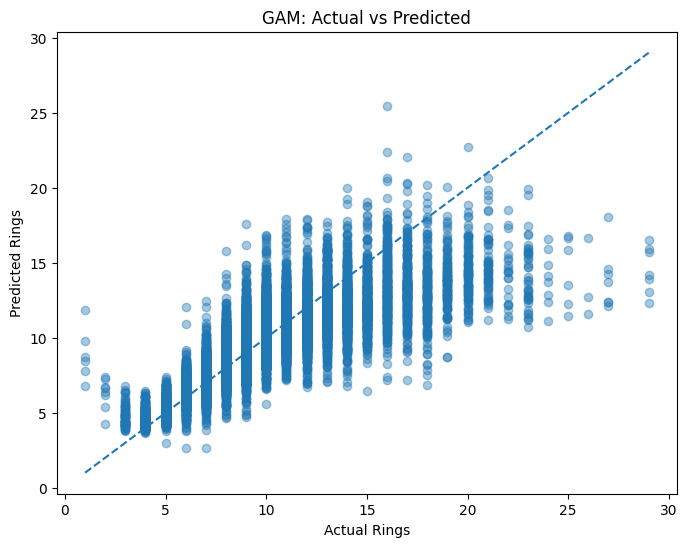

In [73]:
# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_valid_original, gam_preds, alpha=0.4)

plt.plot(
    [y_valid_original.min(), y_valid_original.max()],
    [y_valid_original.min(), y_valid_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("GAM: Actual vs Predicted")
plt.show()

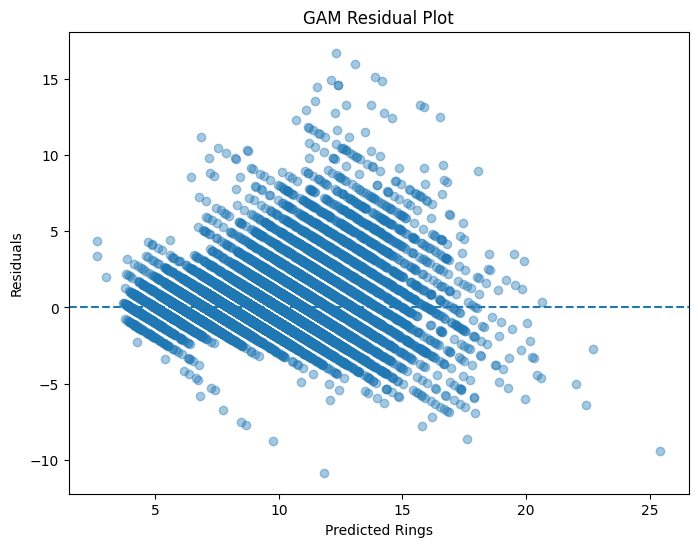

In [74]:
# Residual plot
gam_residuals = y_valid_original - gam_preds

plt.figure(figsize=(8,6))
plt.scatter(gam_preds, gam_residuals, alpha=0.4)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Rings")
plt.ylabel("Residuals")
plt.title("GAM Residual Plot")
plt.show()

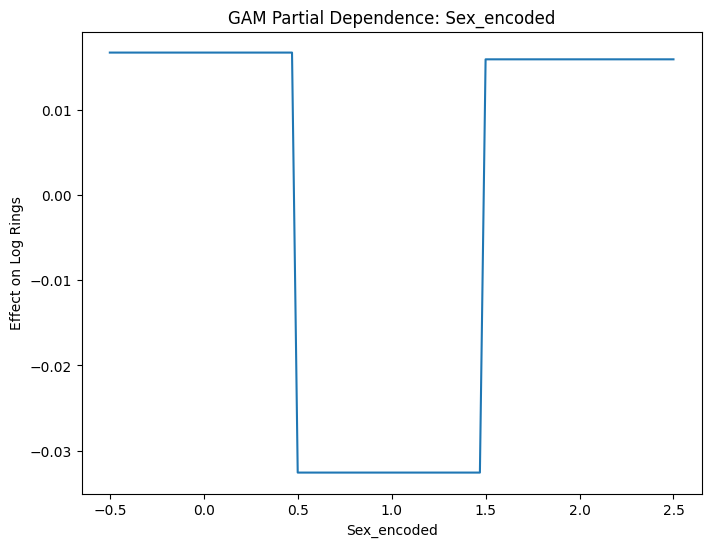

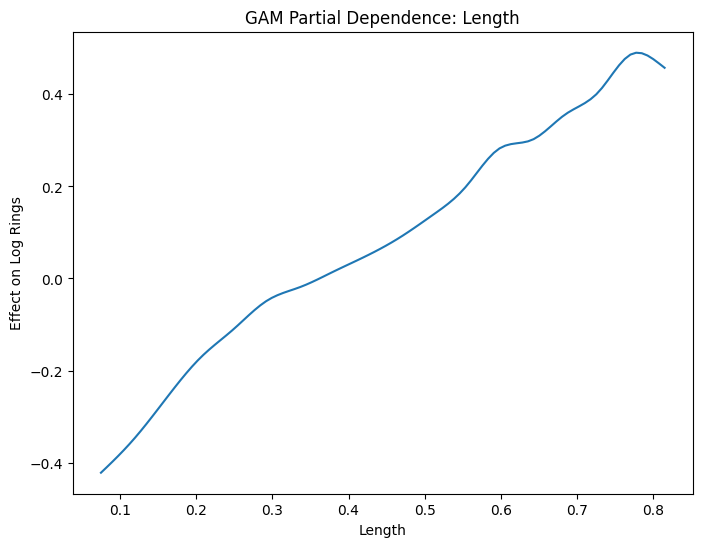

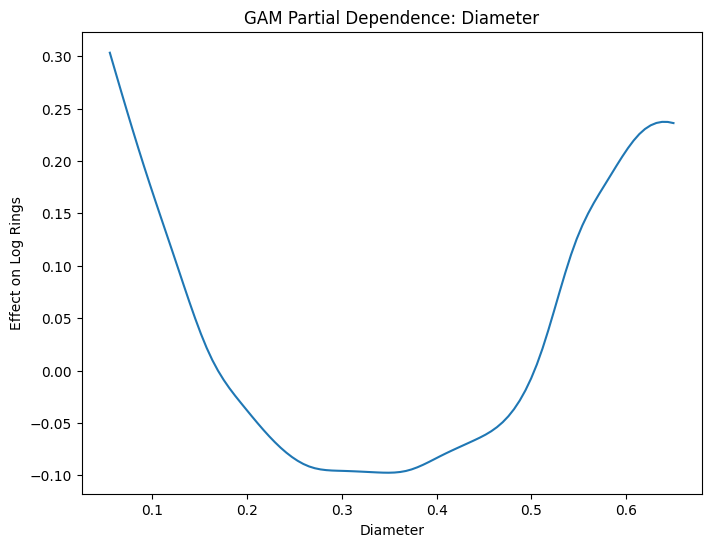

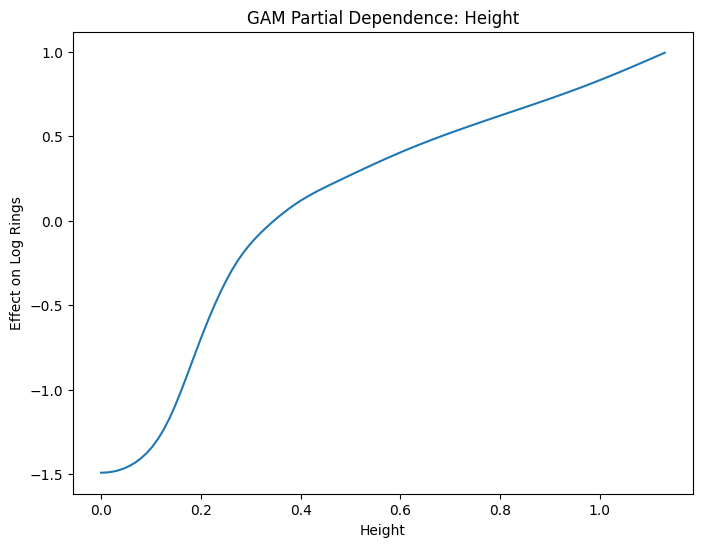

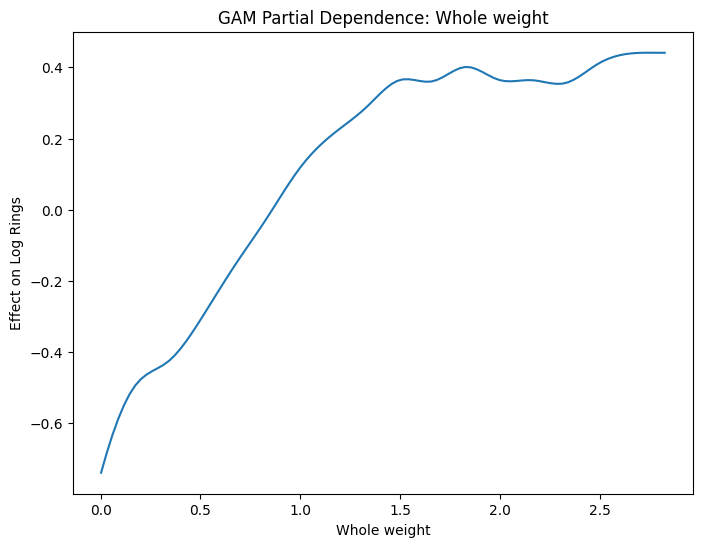

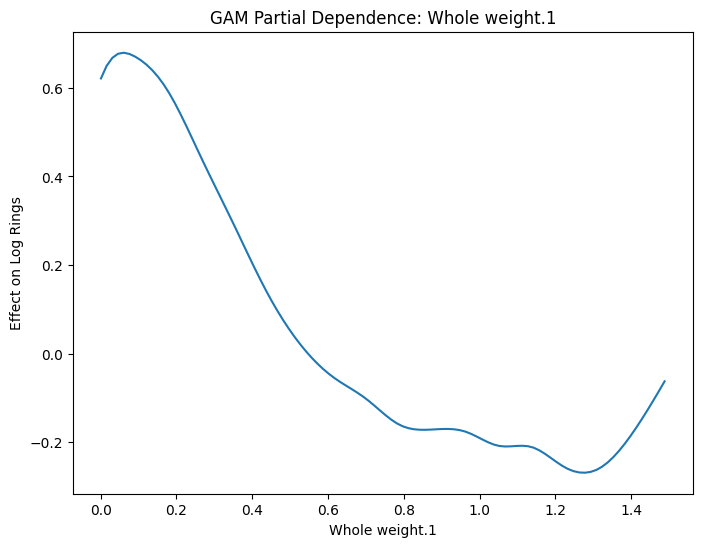

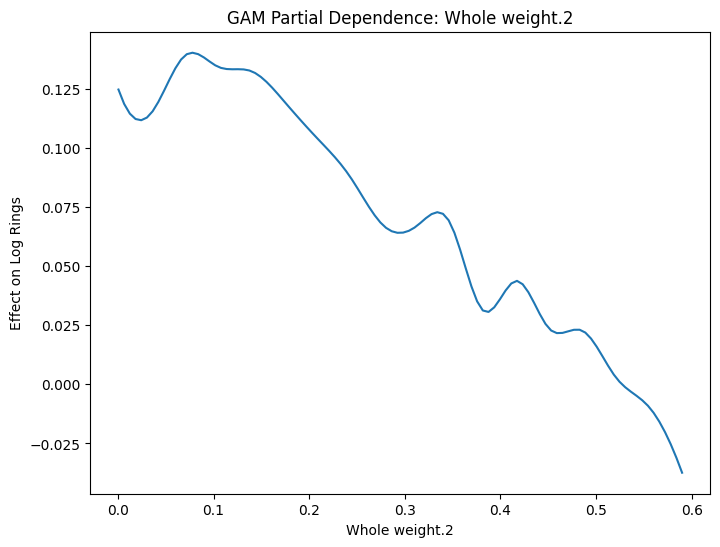

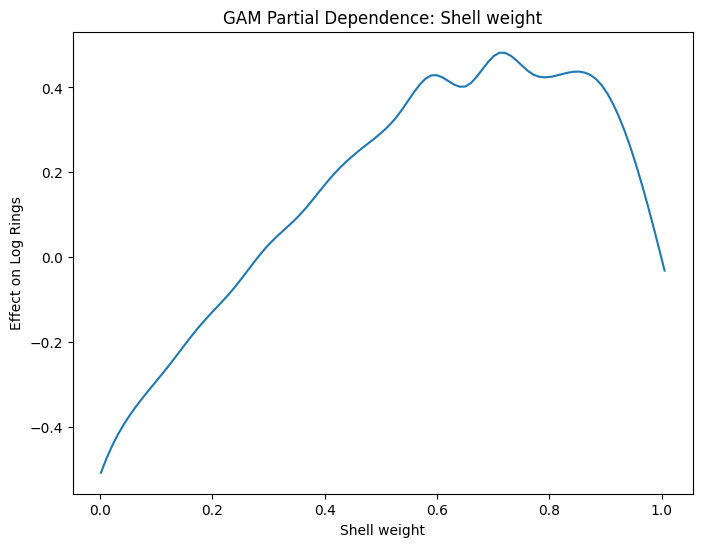

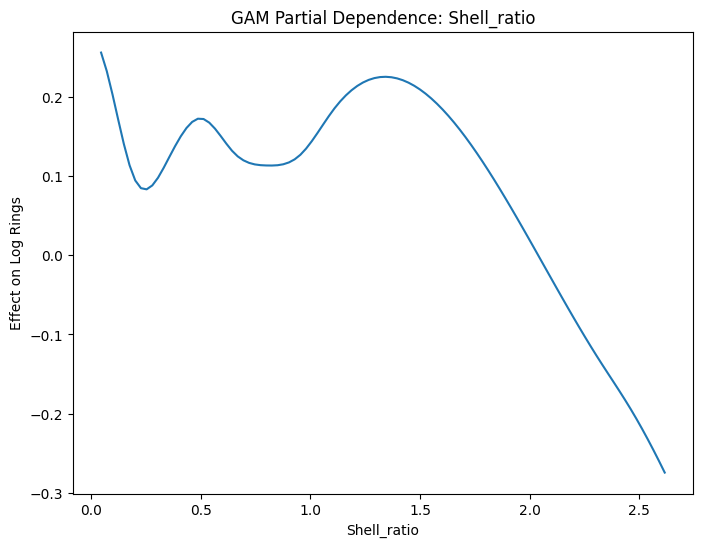

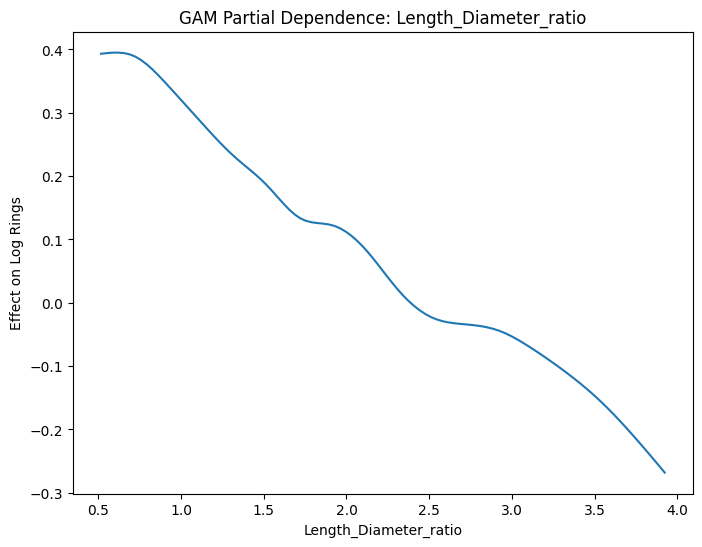

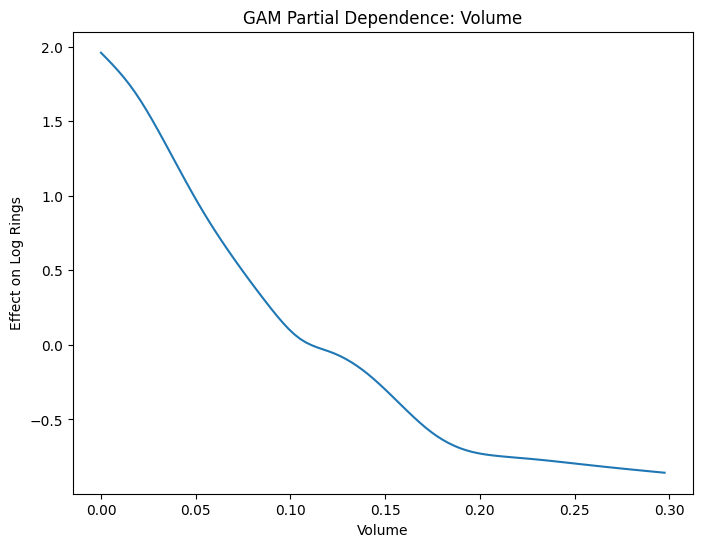

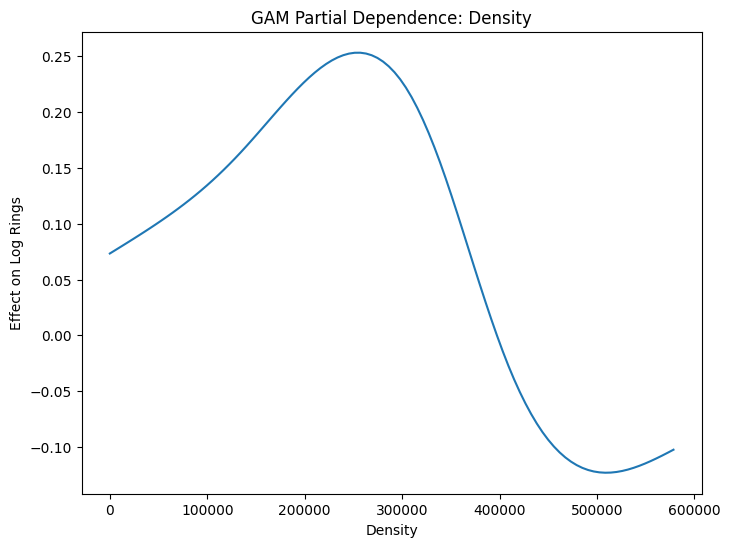

In [75]:
# Partial dependence plots
for i, feature in enumerate(features):
    XX = gam.generate_X_grid(term=i)

    plt.figure(figsize=(8,6))
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.title(f"GAM Partial Dependence: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Effect on Log Rings")
    plt.show()